In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from navisim.navisim_arena import NavisimArena
from navisim.world.sequence_graph import SequenceGraph
from navisim.envs.navisim_env import NavisimEnv


<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/lab/student/anaconda3/envs/navisim_test/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.32.54, Python 3.10.18)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
from navisim.data.rocksdb import get_db
db = get_db()

[INFO] RocksDB initialized at: /lab/student/ziqi/navisim/assets/rocksdb


In [4]:
list(db._db.keys())

['{"date": "2023_03_29", "session": "0", "sector": "0", "file_name": "boundary"}',
 '{"date": "2023_03_29", "session": "0", "sector": "0", "file_name": "cropped_elevation"}',
 '{"date": "2023_03_29", "session": "0", "sector": "0", "file_name": "elevation"}',
 '{"date": "2023_03_29", "session": "0", "sector": "0", "file_name": "occupancy"}',
 '{"date": "2023_03_29", "session": "0", "sector": "0", "file_name": "raw_elevation"}',
 '{"date": "2023_03_29", "session": "0", "sector": "1", "file_name": "boundary"}',
 '{"date": "2023_03_29", "session": "0", "sector": "1", "file_name": "cropped_elevation"}',
 '{"date": "2023_03_29", "session": "0", "sector": "1", "file_name": "elevation"}',
 '{"date": "2023_03_29", "session": "0", "sector": "1", "file_name": "occupancy"}',
 '{"date": "2023_03_29", "session": "0", "sector": "1", "file_name": "raw_elevation"}',
 '{"date": "2023_03_29", "session": "0", "sector": "10", "file_name": "boundary"}',
 '{"date": "2023_03_29", "session": "0", "sector": "10

In [5]:
from navisim.utils.visualize import visualize_seq_graph

sequence_graph = SequenceGraph(path='../../assets/sequence_graph.gpickle')

In [6]:
from plyfile import PlyData
import numpy as np

original_path = '../../../Data/12a18dcf-1/point_cloud/iteration_30000/point_cloud.ply'
new_path = '../../../Data/12a18dcf-1/point_cloud/iteration_30000/point_cloud.ply'

def load_ply_data(path):
    """Load PLY data and return both field names and structured array."""
    plydata = PlyData.read(path)
    data = plydata.elements[0].data
    return data.dtype.names, data

def assert_ply_equal(path1, path2):
    """Assert that two PLY files have the same fields and values."""
    fields1, data1 = load_ply_data(path1)
    fields2, data2 = load_ply_data(path2)

    assert fields1 == fields2, f"Field mismatch:\n{fields1} != {fields2}"
    assert len(data1) == len(data2), f"Number of rows mismatch: {len(data1)} != {len(data2)}"

    for name in fields1:
        arr1 = data1[name]
        arr2 = data2[name]

        if np.issubdtype(arr1.dtype, np.floating):
            assert np.allclose(arr1, arr2, atol=1e-6), f"Mismatch in field '{name}'"
        else:
            assert np.array_equal(arr1, arr2), f"Mismatch in field '{name}'"

    print("✅ PLY files match in both structure and values.")

# Usage
assert_ply_equal(original_path, new_path)

✅ PLY files match in both structure and values.


In [7]:
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

fps_records = []
time_taken_to_load = []

def show_image_in_notebook(pixels, step=None, fps = None): 
    clear_output(wait=True)
    plt.imshow(pixels)
    plt.axis("off")
    fps_records.append(fps)
    if step is not None:
        plt.title(f"Step {step}" + f'({fps:.2f} fps)' if fps else '')
    plt.show()
    plt.pause(0.5) 

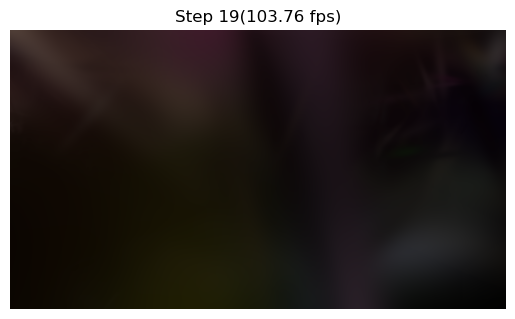

0

In [8]:
num_steps =20

from navisim.enums.enums import RenderMode
from navisim.envs.game_window import GameWindow

import os
os.environ["SDL_VIDEODRIVER"] = "dummy"

window = GameWindow(width = 1280, height=720)
render_mode = RenderMode.NONE
env = NavisimEnv(sequence_graph=sequence_graph, render_mode=render_mode, window=window)

arena = NavisimArena(env = env)
arena.run_episode(num_steps, on_render=show_image_in_notebook)

In [9]:
import pandas as pd
df = pd.read_csv("resource_log.csv")
df.columns


Index(['timestamp', 'render_step', 'render_fps', 'render_time_s',
       'cpu_percent', 'memory_percent', 'memory_used_MB', 'memory_total_MB',
       'gpu_id', 'gpu_name', 'gpu_load_percent', 'gpu_mem_used_MB',
       'gpu_mem_free_MB', 'gpu_temp_C'],
      dtype='object')

In [11]:
import matplotlib.pyplot as plt

'''
GPU Load % and Memory Used
'''
gpu_df = df[df['gpu_id'] == 0]
gpu_df.head()


,timestamp,render_step,render_fps,render_time_s,cpu_percent,memory_percent,memory_used_MB,memory_total_MB,gpu_id,gpu_name,gpu_load_percent,gpu_mem_used_MB,gpu_mem_free_MB,gpu_temp_C
0,2025-06-27 19:48:14,0,146.684759,0.006817,1.2,10.0,35421,385608,0,Tesla V100-SXM2-32GB,6.0,16465.0,16035.0,45.0
4,2025-06-27 19:48:14,1,75.357157,0.013270,12.7,10.0,35431,385608,0,Tesla V100-SXM2-32GB,4.0,16625.0,15875.0,45.0
8,2025-06-27 19:48:15,2,117.116801,0.008538,13.2,10.0,35445,385608,0,Tesla V100-SXM2-32GB,2.0,16625.0,15875.0,45.0
12,2025-06-27 19:48:16,3,72.339284,0.013824,12.8,10.0,35446,385608,0,Tesla V100-SXM2-32GB,0.0,16789.0,15711.0,45.0
16,2025-06-27 19:48:17,4,116.063534,0.008616,13.2,10.0,35455,385608,0,Tesla V100-SXM2-32GB,0.0,16789.0,15711.0,45.0


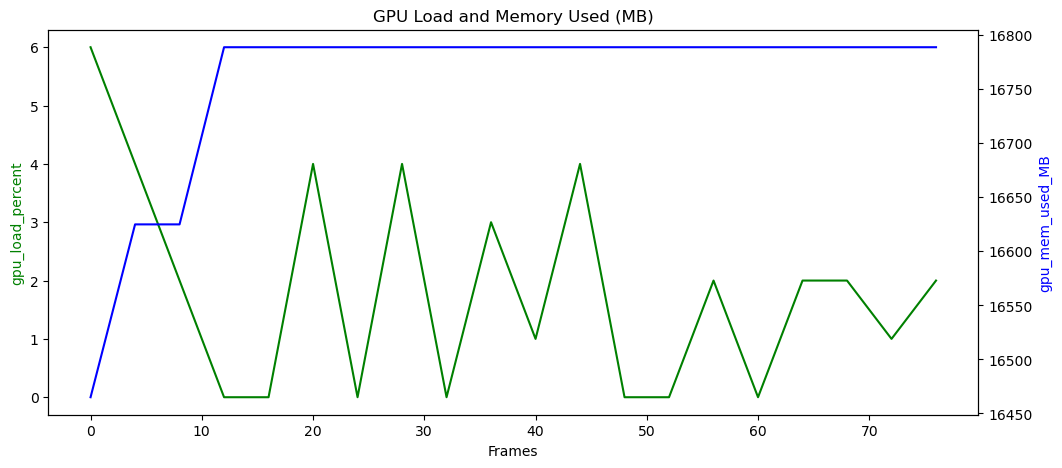

In [12]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.set_title("GPU Load and Memory Used (MB)")

ax2 = ax1.twinx()

ax1.plot(gpu_df[['gpu_load_percent']], 'g-')
ax2.plot(gpu_df[['gpu_mem_used_MB']], 'b-')

ax1.set_xlabel('Frames')
ax1.set_ylabel('gpu_load_percent', color='g')
ax2.set_ylabel('gpu_mem_used_MB', color='b')

plt.show()

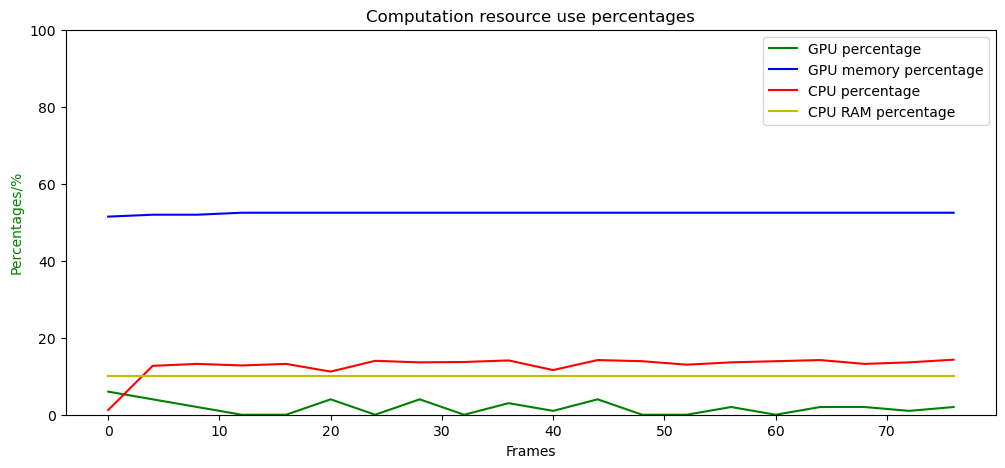

In [13]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.set_title("Computation resource use percentages")

ax1.plot(gpu_df[['gpu_load_percent']], 'g-', label="GPU percentage")
ax1.plot(gpu_df[['gpu_mem_used_MB']]/320, 'b-', label="GPU memory percentage")
ax1.plot(gpu_df[['cpu_percent']], 'r-', label="CPU percentage")
ax1.plot(gpu_df[['memory_percent']], 'y-', label="CPU RAM percentage")


ax1.set_xlabel('Frames')
ax1.set_ylabel('Percentages/%', color='g')
ax1.set_ylim((0, 100))

plt.legend()
plt.show()

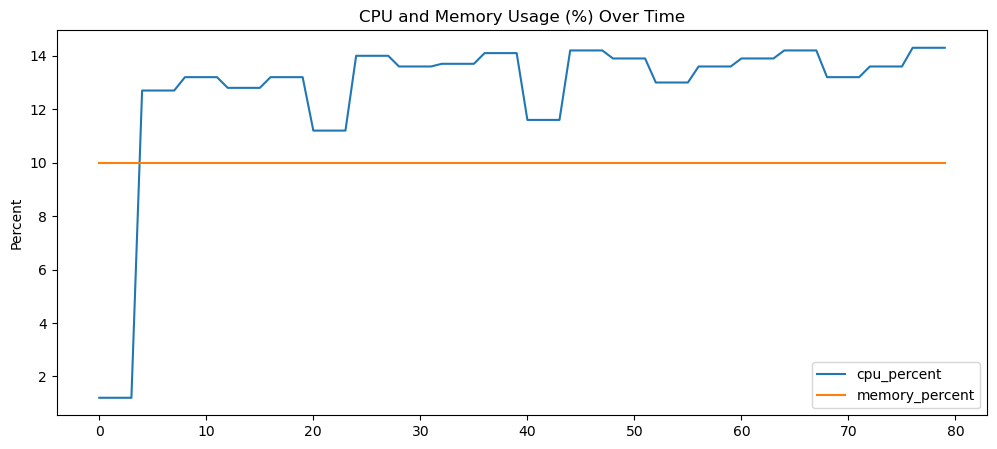

In [14]:
'''
CPU And RAM Usage Over Time
'''
df[['cpu_percent', 'memory_percent']].plot(
    title="CPU and Memory Usage (%) Over Time",
    figsize=(12, 5)
)
plt.ylabel("Percent")
plt.show()

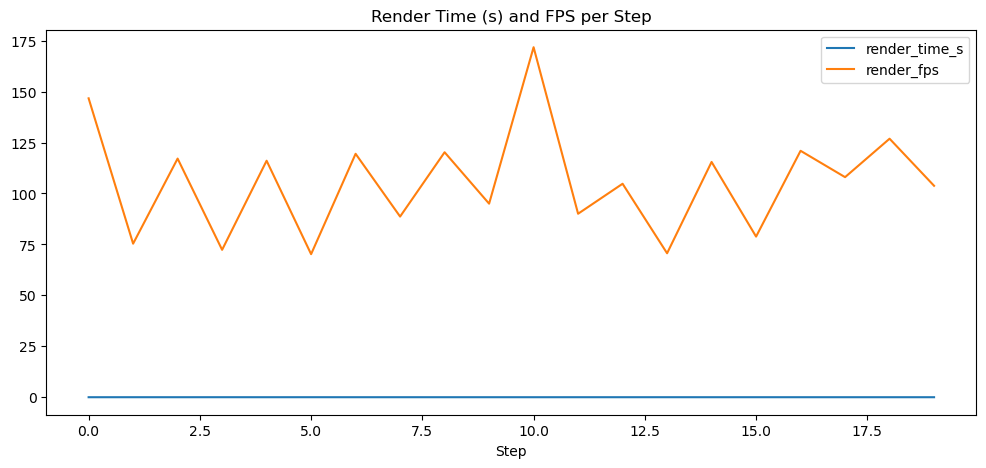

Average Render Time per Step: 0.0100 s
Average FPS: 105.61


In [16]:
'''
Render Time and FPS per Step
'''
df[['render_step', 'render_time_s', 'render_fps']].plot(
    x='render_step',
    y=['render_time_s', 'render_fps'],
    title="Render Time (s) and FPS per Step",
    figsize=(12, 5)
)
plt.xlabel("Step")
plt.show()

avg_render_time = df['render_time_s'].mean()
avg_fps = df['render_fps'].mean()

print(f"Average Render Time per Step: {avg_render_time:.4f} s")
print(f"Average FPS: {avg_fps:.2f}")